In [2]:
%matplotlib inline

# Multilevel RNA similarity

## RNA string
Let an RNA strand be modeled as $T$ a string, with alphabet $A = \{ A, U, C, G\}$, such that $T_i$ is the $i$-th letter and let $|T| = N$ be the size of $S$.
As we already studied in previous lectures, the similarity between two strings can be assessed using distance measures such as the Levenshtein distance.
Each distance relies on specific underlying hypothesis, and serve specific goals.
In this work, we will rely on the Levenshtein to compare RNA strings, at the sequence level.

__Questions:__

+ Download some miRNA sequences from the [miRBase database](http://www.mirbase.org/ftp.shtml)
+ Compute the pairwise Levenshtein distances between the different sequences (use the Levenshtein python library: `pip install python-Levenshtein`).
+ Form groups of sequences that are similar to each other using the `SpectralClustering` object from `sklearn`. Before this, you should first look at the documentation, to know how to use the algorithm, and how it works.
+ Use the `TSNE` object from `sklearn` to represent each string in a 2D space, such that close strings in terms of Levenshtein distance are close in the TSNE embedding space. Again, to do so, first check the documentation, to know how to use the algorithm, and how it works.
+ Plot the location of each RNA string in the TSNE space. The colors should represent the cluster membership. To do so, you can store the X and Y coordinates of the TSNE embedding as well as the cluter memberships in a `pd.DataFrame` and then call the `scatterplot` function of `seaborn`. 
+ For each pair of strings, plot the distance between their TSNE embeddings, as a function of their Levenshtein distance. To do so, you can use the `jointplot` function of `seaborn`.

In [185]:
import seaborn as sns 
from Bio import SeqIO
from Levenshtein import distance
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pandas as pd

Load the first 1000 RNAs from the miRNA fasta file

In [166]:
rnas = list(SeqIO.parse("data/rnas.fa", "fasta"))[:1000]

In [341]:
rnas[:5]

[SeqRecord(seq=Seq('UGAGGUAGUAGGUUGUAUAGUU', SingleLetterAlphabet()), id='cel-let-7-5p', name='cel-let-7-5p', description='cel-let-7-5p MIMAT0000001 Caenorhabditis elegans let-7-5p', dbxrefs=[]),
 SeqRecord(seq=Seq('CUAUGCAAUUUUCUACCUUACC', SingleLetterAlphabet()), id='cel-let-7-3p', name='cel-let-7-3p', description='cel-let-7-3p MIMAT0015091 Caenorhabditis elegans let-7-3p', dbxrefs=[]),
 SeqRecord(seq=Seq('UCCCUGAGACCUCAAGUGUGA', SingleLetterAlphabet()), id='cel-lin-4-5p', name='cel-lin-4-5p', description='cel-lin-4-5p MIMAT0000002 Caenorhabditis elegans lin-4-5p', dbxrefs=[]),
 SeqRecord(seq=Seq('ACACCUGGGCUCUCCGGGUACC', SingleLetterAlphabet()), id='cel-lin-4-3p', name='cel-lin-4-3p', description='cel-lin-4-3p MIMAT0015092 Caenorhabditis elegans lin-4-3p', dbxrefs=[]),
 SeqRecord(seq=Seq('CAUACUUCCUUACAUGCCCAUA', SingleLetterAlphabet()), id='cel-miR-1-5p', name='cel-miR-1-5p', description='cel-miR-1-5p MIMAT0020301 Caenorhabditis elegans miR-1-5p', dbxrefs=[])]

Compute the pairwise Levenshtein distance between the sequences

In [167]:
levenshtein_RNA_distances = np.zeros((len(rnas),len(rnas)))
for i in tqdm(range(len(rnas)-1)):
    for j in range(i+1,len(rnas)):
        levenshtein_RNA_distances[i,j] = distance(str(rnas[i].seq),str(rnas[j].seq))
        levenshtein_RNA_distances[j,i] = levenshtein_RNA_distances[i,j]

Apply the `SpectralClustering` to cluster the RNA strings according to their Levenstein distances

In [249]:
from sklearn.cluster import SpectralClustering
delta = 5
nb_clusters = 5
similarity = np.exp(- levenshtein_RNA_distances ** 2 / (2. * delta ** 2))
sc = SpectralClustering(n_clusters = nb_clusters,affinity="precomputed")
clusters = sc.fit_predict(similarity)
clusters = clusters.astype(str)

Apply the `TSNE` to find a 2D embedding representing the RNA strings 

In [250]:
from sklearn.manifold import TSNE
tsne = TSNE(metric="precomputed",perplexity=30)
rna_levenstein_tsne = tsne.fit_transform(levenshtein_RNA_distances)

Create a `pd.DataFrame` containing the embeddings and the cluster memberships and plot the embedded representations of the RNA strings

In [251]:
rna_levenstein_tsne = pd.DataFrame(rna_levenstein_tsne,columns=["x_tsne","y_tsne"])
rna_levenstein_tsne["cluster"] = clusters
rna_levenstein_tsne["cluster"] = rna_levenstein_tsne["cluster"]+"_cluster"

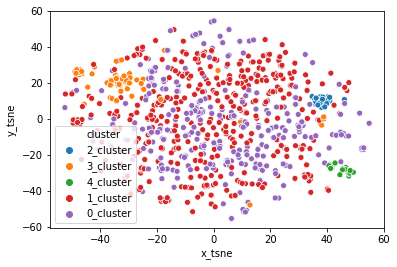

In [257]:
sns.scatterplot(data=rna_levenstein_tsne, x="x_tsne", y="y_tsne",hue="cluster")

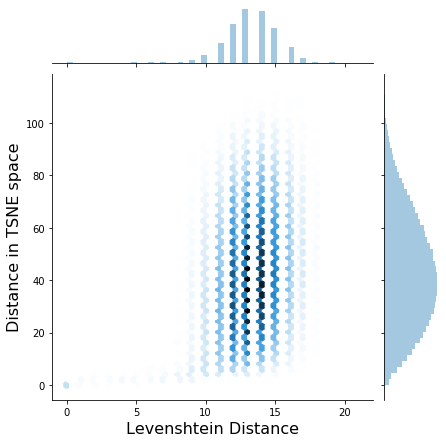

In [253]:
from sklearn.metrics import pairwise_distances

pairwise_distances_tsne_flatten = pairwise_distances(rna_levenstein_tsne[["x_tsne","y_tsne"]]).flatten()
levenshtein_RNA_distances_flatten = levenshtein_RNA_distances.flatten()

g = sns.jointplot(
    x=levenshtein_RNA_distances_flatten,
    y=pairwise_distances_tsne_flatten,
    kind="hex",
)
g.set_axis_labels('Levenshtein Distance', 'Distance in TSNE space', fontsize=16)



## RNA secondary structure prediction
Two nucleic acid polymers of a single RNA string can undergo basepairing interactions through hydrogen bonds (A with U and C with G)
These interactions lead the RNA single stranded string to form intricate 2D and 3D structures.

Let two pairs $i,j$ s.t. $1\leq i \leq j \leq N$ be two pairs of indexes, an RNA secondary structure is simply $S$ a set of pairs of nodes, each pair represents the nucleotides that are connected in the structure.

RNA secondary structures should obey some constrains, otherwise the structure would be thermodynamically unstable, or the prediction problem too difficult (and only little realism is gained) according to [Zucker et al. 1984](https://www.sciencedirect.com/science/article/abs/pii/S0092824084800622):

+ Letter $A$ can only be paired with a letter $U$ and letter $C$ can only be paired with letter $G$. 
+ Moreover a letter can only be paired with one other letter (avoid conflicting pairs), i.e. if $\langle i,j \rangle \in S$ then $\nexists k $ s.t. $\langle i,k\rangle \in S$ 
+ Finally the structure should describe a planar graph: therefore if $h<i<j<k$ then a structure $S$ cannot contain a pair $\langle h,j \rangle$ and $\langle i,k \rangle$

Different algorithms have been proposed so far, to find a set of pairs $S$ that maximizes the free energy of the RNA string (objective function). 
In this work we will use the well-known [Vienna algorithm](https://www.researchgate.net/publication/51828551_ViennaRNA_package_20) to infer the secondary structure of an RNA string.

__Questions:__
+ Use the ViennaRNA python package (`import RNA`) to compute the secondary structures of the sequences loaded in the previous section.
    + How does this algorithm work?
    + Use the `fc = RNA.fold_compound(seq)` function to create an RNA fold object for sequence `seq`
    + Then use the `fc.mfe()` method to find the secondary structure that optimizes the Minimal Free Energy (MFE). This methods returns a tuple containing the structure the MFE itself.
    + Take a look at the structure, how are the bonds represented?
+ The secondary structure is represented as a string, therefore the Levenshtein distance can be used to compare the secondary structures of the RNA strings as in the previous section.
+ Form groups of sequences that have similar secondary structure string representations, using the `SpectralClustering` object from `sklearn`. Before this, you should first look at the documentation, to know how to use the algorithm, and how it works.
+ Use the `TSNE` object from `sklearn` to represent each string in a 2D space, such that close strings in terms of Levenshtein distance are close in the TSNE embedding space. Again, to do so, first check the documentation, to know how to use the algorithm, and how it works.
+ Plot the location of each RNA string in the TSNE space. The colors should represent the cluster membership. To do so, you can store the X and Y coordinates of the TSNE embedding as well as the cluter memberships in a `pd.DataFrame` and then call the `scatterplot` function of `seaborn`. 
+ For each pair of strings, plot the distance between their TSNE embeddings, as a function of their Levenshtein distance. To do so, you can use the `jointplot` function of `seaborn`.
+ For each pair of strings plot their nucleotides string Levenshtein distance as a function of their secondary structure string  Levenshtein distance.

In [181]:
"""
# in case you need to install the libraries in Colab
!wget -c https://repo.anaconda.com/miniconda/Miniconda3-4.5.4-Linux-x86_64.sh
!chmod +x Miniconda3-4.5.4-Linux-x86_64.sh
!bash ./Miniconda3-4.5.4-Linux-x86_64.sh -b -f -p /usr/local
# update 1
!conda install -q -y --prefix /usr/local python=3.6 ujson
# https://www.tbi.univie.ac.at/RNA/ViennaRNA/doc/html/examples_python.html
# update 2
import sys
sys.path.append('/usr/local/lib/python3.6/site-packages')
!conda install -q -y  -c bioconda viennarna
"""

"\n!wget -c https://repo.anaconda.com/miniconda/Miniconda3-4.5.4-Linux-x86_64.sh\n!chmod +x Miniconda3-4.5.4-Linux-x86_64.sh\n!bash ./Miniconda3-4.5.4-Linux-x86_64.sh -b -f -p /usr/local\n# update 1\n!conda install -q -y --prefix /usr/local python=3.6 ujson\n# https://www.tbi.univie.ac.at/RNA/ViennaRNA/doc/html/examples_python.html\n# update 2\nimport sys\nsys.path.append('/usr/local/lib/python3.6/site-packages')\n!conda install -q -y  -c bioconda viennarna\n"

Infer the sequences secondary structures and store them

In [173]:
import RNA
mfes = []
mfe_structs = []
for rna in tqdm(rnas):
    fc = RNA.fold_compound(str(rna.seq))
    (mfe_struct, mfe) = fc.mfe() 
    mfes.append(mfe)
    mfe_structs.append(mfe_struct)


Compute the Levenshtein distance between the secondary structure string representations

In [174]:
levenshtein_secondary_string_distances = np.zeros((len(rnas),len(rnas)))
for i in tqdm(range(len(rnas)-1)):
    for j in range(i+1,len(rnas)):
        levenshtein_secondary_string_distances[i,j] = distance(mfe_structs[i],mfe_structs[j])
        levenshtein_secondary_string_distances[j,i] = levenshtein_secondary_string_distances[i,j]

Apply the `SpectralClustering` to cluster the RNA strings according to their Levenstein distances (for the secondary structure string representation)

In [333]:
from sklearn.cluster import SpectralClustering
delta = 5
nb_clusters = 10
similarity = np.exp(- levenshtein_secondary_string_distances ** 2 / (2. * delta ** 2))
sc = SpectralClustering(n_clusters = nb_clusters,affinity="precomputed")
clusters_secondary = sc.fit_predict(similarity)
clusters_secondary = clusters_secondary.astype(str)

Apply the `TSNE` to find a 2D embedding representing the RNA secondary structure strings 

In [334]:
from sklearn.manifold import TSNE
tsne = TSNE(metric="precomputed",perplexity=20)
rna_secondary_levenstein_tsne = tsne.fit_transform(levenshtein_secondary_string_distances)


Create a `pd.DataFrame` containing the embeddings and the cluster memberships and plot the embedded representations of the RNA econdary structure strings

In [335]:
rna_secondary_levenstein_tsne = pd.DataFrame(rna_secondary_levenstein_tsne,columns=["x_tsne","y_tsne"])
rna_secondary_levenstein_tsne["cluster"] = clusters_secondary
rna_secondary_levenstein_tsne["cluster"] = rna_secondary_levenstein_tsne["cluster"]+"_cluster"

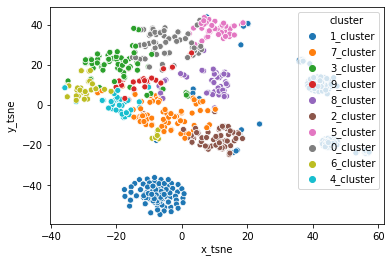

In [350]:
sns.scatterplot(data=rna_secondary_levenstein_tsne, x="x_tsne", y="y_tsne",hue="cluster")

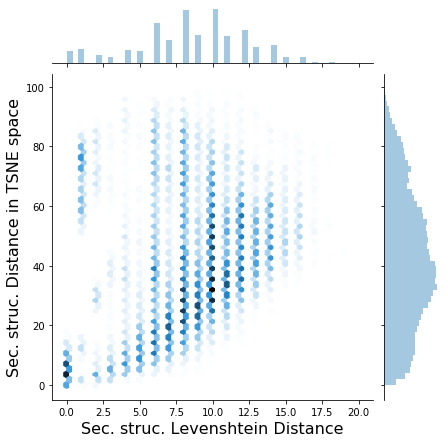

In [337]:
from sklearn.metrics import pairwise_distances

pairwise_distances_tsne_seccondary_flatten = pairwise_distances(rna_secondary_levenstein_tsne[["x_tsne","y_tsne"]]).flatten()
levenshtein_RNA_seccondary_distances_flatten = levenshtein_secondary_string_distances.flatten()

g = sns.jointplot(
    x=levenshtein_RNA_seccondary_distances_flatten,
    y=pairwise_distances_tsne_seccondary_flatten,
    kind="hex",
)
g.set_axis_labels('Sec. struc. Levenshtein Distance', 'Sec. struc. Distance in TSNE space', fontsize=16)


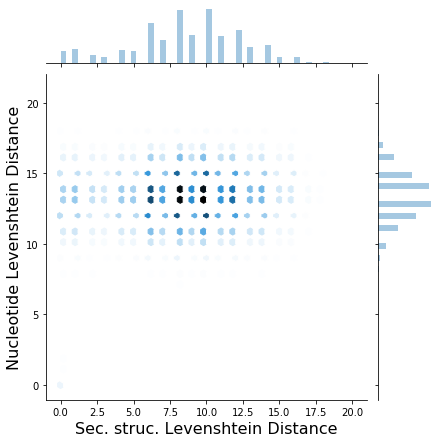

In [338]:
g = sns.jointplot(
    x=levenshtein_RNA_seccondary_distances_flatten,
    y=levenshtein_RNA_distances_flatten,
    kind="hex",
)
g.set_axis_labels('Sec. struc. Levenshtein Distance', 'Nucleotide Levenshtein Distance', fontsize=16)


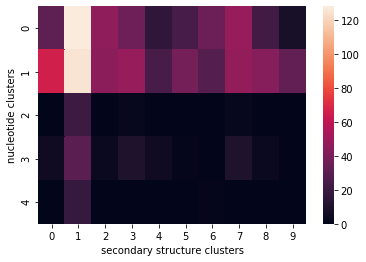

In [339]:
cluster_memberships = pd.DataFrame({"nucleotide clusters":clusters,
                                    "secondary structure clusters": clusters_secondary})
cross_tab = pd.crosstab(cluster_memberships["nucleotide clusters"],cluster_memberships["secondary structure clusters"])
sns.heatmap(cross_tab)

In [340]:
from Levenshtein import median
clustered_sec_strings = pd.DataFrame({"cluster":clusters_secondary, "structure":mfe_structs})
gb = clustered_sec_strings.groupby("cluster")
for group in gb.groups:
    print(group,median(gb.get_group(group)["structure"]))

0 .((((......)))).......
1 ......................
2 ........((((....)))).
3 ..((((.........))))...
4 ..((((.(((....))).))))
5 ((((....))))..........
6 ....((((........)))))
7 .....(((((.....)))))..
8 ....((((....))))......
9 (((((((....)))))))...


## RNA secondary structures as graphs

__Question__
+ Another way to represent an RNA secondary structure is using a graph, propose a formalization of such a model.
+ Write a function `rnasecstruc_2_graph` that converts the secondary structure string into a NetworkX graph. Add the nucleotide type as a node label, and the type of link as an edge label.
+ Write a function to plot their secondary structure graph
+ Install the [grakel](https://ysig.github.io/GraKeL/latest/) library that implements different graphs kernels (i.e., similarity function that can applied to graphs)

In [ ]:
"""
!pip install grakel
!pip install networkx
"""

In [368]:
import networkx as nx
import grakel

def rnasecstruc_2_graph(rna,struct):
    nodes = list(rna)
    G = nx.Graph()
    for i in range(len(rna)):
        G.add_node(rna[i]+"|"+str(i),label=rna[i])
    for i in range(1,len(rna)):
        G.add_edge(rna[i-1]+"|"+str(i-1),rna[i]+"|"+str(i), tabel="string")
    open_link = []
    for i in range(len(rna)):
        if struct[i] == "(":
            open_link.append(rna[i]+"|"+str(i))
        elif struct[i] == ")":
            last_open = open_link.pop()
            G.add_edge(last_open,rna[i]+"|"+str(i), tabel="hydrogene")
        else:
            pass
    return G

def plot_secondary_structure(G):
    pos = nx.kamada_kawai_layout(G)
    nx.draw(G,pos=pos,with_labels=True,font_size=7,node_size=70,alpha=0.5)


1000


/Users/sergiopeignier/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:579: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if not cb.iterable(width):


[{'A|0': {'C|1': 1.0},
  'C|1': {'A|0': 1.0, 'A|2': 1.0},
  'A|2': {'C|1': 1.0, 'C|3': 1.0, 'U|18': 1.0},
  'C|3': {'A|2': 1.0, 'C|4': 1.0, 'G|17': 1.0},
  'C|4': {'C|3': 1.0, 'U|5': 1.0, 'G|16': 1.0},
  'U|5': {'C|4': 1.0, 'G|6': 1.0, 'G|15': 1.0},
  'G|6': {'U|5': 1.0, 'G|7': 1.0, 'C|14': 1.0},
  'G|7': {'G|6': 1.0, 'G|8': 1.0, 'C|13': 1.0},
  'G|8': {'G|7': 1.0, 'C|9': 1.0},
  'C|9': {'G|8': 1.0, 'U|10': 1.0},
  'U|10': {'C|9': 1.0, 'C|11': 1.0},
  'C|11': {'U|10': 1.0, 'U|12': 1.0},
  'U|12': {'C|11': 1.0, 'C|13': 1.0},
  'C|13': {'U|12': 1.0, 'C|14': 1.0, 'G|7': 1.0},
  'C|14': {'C|13': 1.0, 'G|15': 1.0, 'G|6': 1.0},
  'G|15': {'C|14': 1.0, 'G|16': 1.0, 'U|5': 1.0},
  'G|16': {'G|15': 1.0, 'G|17': 1.0, 'C|4': 1.0},
  'G|17': {'G|16': 1.0, 'U|18': 1.0, 'C|3': 1.0},
  'U|18': {'G|17': 1.0, 'A|19': 1.0, 'A|2': 1.0},
  'A|19': {'U|18': 1.0, 'C|20': 1.0},
  'C|20': {'A|19': 1.0, 'C|21': 1.0},
  'C|21': {'C|20': 1.0}},
 {'A|0': 'A',
  'C|1': 'C',
  'A|2': 'A',
  'C|3': 'C',
  'C|4': 'C'

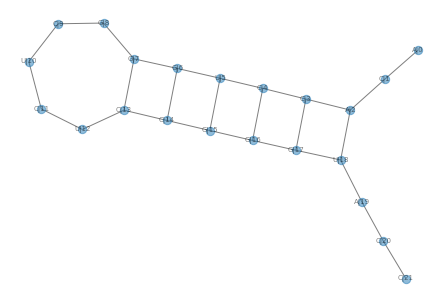

In [412]:
G_train = [rnasecstruc_2_graph(rnas[i].seq, mfe_structs[i]) for i, rna in enumerate(rnas)]
G_train_grakel = list(grakel.graph_from_networkx(G_train,
                                                node_labels_tag='label',
                                                edge_labels_tag="tabel",
                                                as_Graph=False))
print(len(G_train))

G = G_train[3]
plot_secondary_structure(G)
G_train_grakel[3]

In [484]:
from grakel.utils import graph_from_networkx
from grakel.kernels import RandomWalk,WeisfeilerLehman, Propagation, VertexHistogram,GraphletSampling,HadamardCode
#wl_kernel = WeisfeilerLehman(n_iter=1, normalize=True, base_graph_kernel=VertexHistogram)
#wl_kernel = RandomWalk( normalize=True)
wl_kernel = HadamardCode( normalize=True)


In [485]:
K_train = wl_kernel.fit_transform(G_train_grakel)

In [486]:
K_train

array([[1.        , 0.40436838, 0.5342173 , ..., 0.38561494, 0.60847558,
        0.52471935],
       [0.40436838, 1.        , 0.5592722 , ..., 0.73667948, 0.47973419,
        0.44908631],
       [0.5342173 , 0.5592722 , 1.        , ..., 0.57268605, 0.59026439,
        0.54268821],
       ...,
       [0.38561494, 0.73667948, 0.57268605, ..., 1.        , 0.46182575,
        0.43300679],
       [0.60847558, 0.47973419, 0.59026439, ..., 0.46182575, 1.        ,
        0.61220465],
       [0.52471935, 0.44908631, 0.54268821, ..., 0.43300679, 0.61220465,
        1.        ]])

Apply the SpectralClustering to cluster the RNA strings according to their Levenstein distances (for the secondary structure string representation)


In [507]:

from sklearn.cluster import SpectralClustering
delta = 5
nb_clusters = 5
similarity = K_train
sc = SpectralClustering(n_clusters = nb_clusters,affinity="precomputed")
clusters_secondary_kernel = sc.fit_predict(similarity)
clusters_secondary_kernel = clusters_secondary_kernel.astype(str)


Apply the `TSNE` to find a 2D embedding representing the RNA secondary structure strings 

In [515]:
from sklearn.manifold import TSNE
tsne = TSNE(metric="precomputed",perplexity=30)
rna_secondary_kernel_tsne = tsne.fit_transform(K_train)


Create a `pd.DataFrame` containing the embeddings and the cluster memberships and plot the embedded representations of the RNA econdary structure strings

In [516]:
rna_secondary_kernel_tsne = pd.DataFrame(rna_secondary_kernel_tsne,columns=["x_tsne","y_tsne"])
rna_secondary_kernel_tsne["cluster"] = clusters_secondary_kernel
rna_secondary_kernel_tsne["cluster"] = rna_secondary_kernel_tsne["cluster"]+"_cluster"

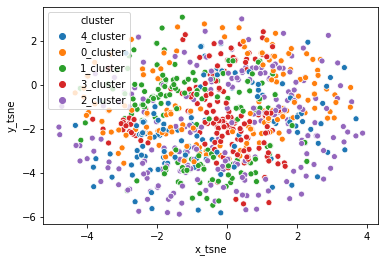

In [517]:
sns.scatterplot(data=rna_secondary_kernel_tsne, x="x_tsne", y="y_tsne",hue="cluster")

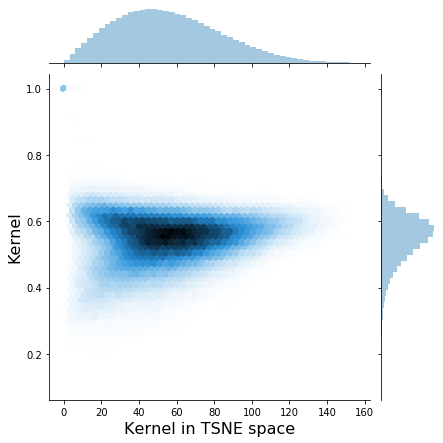

In [511]:
from sklearn.metrics import pairwise_distances

pairwise_distances_tsne_secondary_kernel_flatten = pairwise_distances(rna_secondary_kernel_tsne[["x_tsne","y_tsne"]]).flatten()
K_train_flatten = K_train.flatten()

g = sns.jointplot(
    x=pairwise_distances_tsne_secondary_kernel_flatten,
    y=K_train_flatten,
    kind="hex",
)
g.set_axis_labels('Kernel in TSNE space', 'Kernel', fontsize=16)
